# Variable과 자동 미분(Autograd), 그리고 Matplotlib 시각화

이 노트북은 PyTorch의 Tensor, 자동 미분(`autograd`), 역전파(`backward`) 개념을 이해하고, 선형 회귀 모델의 학습 과정을 `Matplotlib` 그래프로 확인할 수 있도록 구성한 실습 자료입니다.


## Matplotlib 사용 방법 상세 설명

Matplotlib은 파이썬에서 가장 널리 사용되는 그래프 시각화 라이브러리입니다. 딥러닝 학습 과정에서는 손실값(loss), 가중치(weight), 편향(bias), 예측 결과 등을 그래프로 표현하여 모델이 제대로 학습되고 있는지 확인할 수 있습니다.

### 1. Matplotlib 불러오기

```python
import matplotlib.pyplot as plt
```

`pyplot`은 그래프를 그릴 때 자주 사용하는 함수들을 모아 둔 모듈이며, 일반적으로 `plt`라는 별칭으로 사용합니다.

### 2. 선 그래프 그리기

```python
plt.plot(epoch_list, loss_list)
plt.show()
```

`plt.plot()`은 값의 변화를 선 그래프로 표현합니다. 학습이 진행될수록 손실값이 줄어드는지 확인할 때 사용합니다.

### 3. 산점도 그리기

```python
plt.scatter(X, y)
plt.show()
```

`plt.scatter()`는 데이터의 분포를 점으로 표현합니다. 입력값과 정답값이 어떤 관계를 가지는지 확인할 때 사용합니다.

### 4. 학습 결과 시각화

학습 전후의 예측선을 그래프로 그리면 모델이 데이터를 얼마나 잘 따라가도록 학습되었는지 직관적으로 확인할 수 있습니다.

이 노트북에서는 W&B 로그 기록 대신 리스트에 학습 기록을 저장하고, 학습이 끝난 뒤 Matplotlib으로 그래프를 출력합니다.


## 1. 필요한 라이브러리 불러오기


In [ ]:
# PyTorch는 딥러닝 모델을 만들고 학습시키기 위한 대표적인 파이썬 라이브러리입니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등 딥러닝 모델 구성에 필요한 기능을 제공합니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# matplotlib.pyplot은 학습 결과를 그래프로 시각화하기 위해 사용하는 라이브러리입니다.
# W&B처럼 외부 서비스에 로그인하지 않아도 구글 코랩에서 바로 그래프를 확인할 수 있습니다.
import matplotlib.pyplot as plt

# SimpleNamespace는 딕셔너리처럼 저장한 설정값을 config.learning_rate처럼 점 표기법으로 읽기 위해 사용합니다.
# 예를 들어 config.learning_rate는 학습률 값을 의미합니다.
from types import SimpleNamespace

# 재현 가능한 실험을 위해 난수 시드를 고정합니다.
# 같은 코드를 다시 실행해도 가능한 한 비슷한 초기값과 결과가 나오도록 도와줍니다.
torch.manual_seed(42)

# 현재 설치된 PyTorch 버전을 출력하여 실행 환경을 확인합니다.
print("PyTorch 버전:", torch.__version__)


PyTorch 버전: 2.11.0+cpu


## 실험 1 : rand seed 고정



## 딥러닝 재현성(Seed) 고정 명령어 및 예시 총정리 표

| 명령어 | 제어 대상 | 진짜 목적 | 영향 예시 (코드 및 상황) |
| :--- | :--- | :--- | :--- |
| `random.seed(42)` | 파이썬 기본 난수 | 일반 소스코드 레벨 데이터 셔플 고정 | `import random`<br>`items = ['사과', '바나나', '포도']`<br>`random.shuffle(items)`<br>→ 리스트가 매번 똑같은 순서로 섞임 |
| `np.random.seed(42)` | 넘파이(NumPy) 난수 | 외부 데이터 전처리/증강 라이브러리 고정 | `Albumentations`, `OpenCV` 등을 활용한 데이터 전처리 시,<br>이미지가 랜덤으로 좌우 반전되는 연산의 순서와 방향을 고정함 |
| `torch.manual_seed(42)` | 파이토치 CPU 난수 | 모델 초기 가중치(CPU) 및 난수 고정 | `import torch.nn as nn`<br>`model = nn.Linear(10, 5)`<br>→ CPU 메모리 선언 시 초기 가중치($w$) 숫자가 항상 동일함 |
| `torch.cuda.manual_seed_all(42)` | 파이토치 GPU 난수 | 드롭아웃 및 가중치(GPU) 고정 | `model.cuda()` 환경에서 학습할 때,<br>`nn.Dropout(p=0.5)`이 무작위로 뉴런을 끄는 위치를 매번 똑같이 통제함 |
| `torch.backends.cudnn.deterministic = True` | cuDNN 연산 방식 | GPU 병렬 계산 순서로 인한 소수점 틀어짐 방지 | `nn.Conv2d(3, 16, kernel_size=3)` (CNN 합성곱)<br>→ 수천 개 코어가 계산 결과를 조립하는 순서를 고정해 소수점 오차 차단 |
| `torch.backends.cudnn.benchmark = False` | cuDNN 최적화 탐색 | 도중에 계산 알고리즘이 멋대로 바뀌는 현상 차단 | 하드웨어가 부하 상태에 따라 연산 지름길(알고리즘)을 임의로 바꾸는 것을 막고, 속도가 느려지더라도 정해진 표준 통로만 고집하게 만듦 |

## 시드 고정 적용 전/후 비교 및 원인 분석 보고

### 1. 전후 지표 비교 표
| 항목 | 1. 적용하기 이전 (무작위) | 2. 적용한 이후 (시드 42 고정) | 변동 원인 및 분석 |
| :--- | :--- | :--- | :--- |
| 초기 가중치 (Weight) | -0.2648 | 0.1564 | 시드 고정으로 모델의 초기 시작점 변경 |
| 초기 편향 (Bias) | 0.1069 | -0.8799 | 시드 고정으로 모델의 초기 시작점 변경 |
| 정답 데이터 (y) 앞 5개 | -8.9273 ~ -8.0934 | -8.0365 ~ -7.8527 | 데이터 생성 시 포함되는 랜덤 노이즈 값이 시드 42 기준으로 고정됨 |
| 최종 가중치 (Weight) | 1.9548 | 1.9971 | 데이터셋과 모델의 시작점이 달라져 다른 최적점으로 수렴함 |
| 최종 편향 (Bias) | 0.8918 | 0.7766 | 데이터셋과 모델의 시작점이 달라져 다른 최적점으로 수렴함 |
| 최종 손실값 (Loss) | 0.2171 | 0.3049 | 변경된 데이터셋 및 가중치에 맞춰 최적의 손실값이 산출됨 |

---

### 2. 핵심 변동 원인 요약

* **시드 고정 엔진 정상 작동:** 적용 이후 난수 생성 결과의 첫 수치가 `0.3367`로 나온 것은 파이토치 글로벌 시드 42가 하드웨어를 정확히 통제했다는 절대적 증거입니다.
* **문제(데이터셋)의 변화:** 선형 회귀 데이터를 생성할 때 기저에 깔리는 무작위 노이즈가 시드 42 규칙에 맞춰 새로 고정되면서, 미세하게 다른 데이터셋이 구축되었습니다.
* **학습 경로의 변화:** 데이터셋이 바뀌고 모델의 출발선(초기 가중치/편향)이 완전히 달라졌기 때문에, 동일한 에포크(100회) 동안 경사하강법(SGD)을 수행한 후 도달한 최종 수렴값과 손실값에 차이가 발생하는 것은 수학적으로 당연한 결과입니다.
* **재현성 확보:** 이 상태에서 코랩 셀을 다시 실행하거나 전체 실행을 하더라도, 앞으로는 가중치 `0.1564`, 최종 손실값 `0.3049`라는 수치가 단 1비트의 오차도 없이 영원히 똑같이 유지됩니다.

In [ ]:

import torch
import numpy as np
import random

# 모든 난수 생성 엔진의 시작점을 42로 통일
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42) # GPU를 쓸 경우를 대비

# 연산 속도를 조금 포기하더라도 무조건 똑같은 결과를 내도록 강제 규칙 적용
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. Tensor 이해

 `Tensor`에 `requires_grad=True`를 설정하여 자동 미분을 사용합니다.


### 2-1. Tensor 생성하기


In [ ]:
# 이 코드를 주석 해제 하거나 아래처럼 generator 를 사용해야 함
# torch.manual_seed(42)

# torch.randn(3, 4)는 평균 0, 표준편차 1을 따르는 난수로 3행 4열 Tensor를 생성합니다.
# Tensor는 PyTorch에서 숫자 데이터를 저장하는 기본 자료구조입니다.
# x_tensor = torch.randn(3, 4)
x_tensor = torch.randn(3, 4, generator=torch.Generator().manual_seed(42))


# 생성된 Tensor의 값을 출력합니다.
# 출력 결과는 실행할 때마다 달라질 수 있지만, 위에서 manual_seed를 설정했기 때문에 재현성이 높아집니다.
print(x_tensor)


tensor([[ 0.3367,  0.1288,  0.2345,  0.2303],
        [-1.1229, -0.1863,  2.2082, -0.6380],
        [ 0.4617,  0.2674,  0.5349,  0.8094]])


### 2-2. 자동 미분이 가능한 Tensor 생성하기


In [ ]:
# torch.manual_seed(42)

# requires_grad=True는 이 Tensor를 이용한 모든 연산을 PyTorch가 추적하겠다는 의미입니다.
# 즉, 나중에 backward()를 호출하면 이 Tensor에 대한 기울기(gradient)를 자동으로 계산할 수 있습니다.
# x = torch.randn(3, 4, requires_grad=True)
x = torch.randn(3, 4, requires_grad=True, generator=torch.Generator().manual_seed(42))


# Tensor의 실제 값을 출력합니다.
print("x 값:")
print(x)

# requires_grad 속성을 확인합니다.
# True이면 자동 미분 대상이고, False이면 자동 미분 대상이 아닙니다.
print("requires_grad:", x.requires_grad)

# 아직 backward()를 실행하지 않았기 때문에 x.grad는 None입니다.
# grad는 손실 함수가 x에 대해 얼마나 민감하게 변하는지를 나타내는 기울기 값입니다.
print("초기 gradient:", x.grad)


x 값:
tensor([[ 0.3367,  0.1288,  0.2345,  0.2303],
        [-1.1229, -0.1863,  2.2082, -0.6380],
        [ 0.4617,  0.2674,  0.5349,  0.8094]], requires_grad=True)
requires_grad: True
초기 gradient: None


### 2-3. `.data`, `.grad`, `.requires_grad` 이해하기


In [ ]:
# .detach()는 현재 Tensor 값을 계산 그래프에서 분리합니다.
# 예전 코드의 .data와 비슷하게 값을 확인하는 용도로 사용할 수 있지만, 안전성을 위해 detach() 사용을 권장합니다.
x_value_only = x.detach()

# 계산 그래프에서 분리된 Tensor 값을 출력합니다.
print("계산 그래프에서 분리된 x 값:")
print(x_value_only)

# x.grad는 현재까지 계산된 x의 기울기를 저장합니다.
# 아직 backward()를 수행하지 않았으므로 None이 출력됩니다.
print("현재 x.grad:", x.grad)

# x.requires_grad는 x가 자동 미분 대상인지 확인하는 속성입니다.
print("x.requires_grad:", x.requires_grad)


계산 그래프에서 분리된 x 값:
tensor([[ 0.3367,  0.1288,  0.2345,  0.2303],
        [-1.1229, -0.1863,  2.2082, -0.6380],
        [ 0.4617,  0.2674,  0.5349,  0.8094]])
현재 x.grad: None
x.requires_grad: True


## 3. 계산 그래프와 자동 미분

PyTorch는 `requires_grad=True`인 Tensor가 연산에 사용되면 계산 과정을 그래프로 기록합니다.  
이 계산 그래프를 이용하여 `backward()` 실행 시 각 변수의 기울기를 자동 계산합니다.


### 3-1. 계산 그래프 만들기


In [ ]:
# torch.manual_seed(42)

# x는 자동 미분 대상 Tensor입니다.
# requires_grad=True이므로 x가 포함된 연산은 계산 그래프에 기록됩니다.
# x = torch.randn(3, 4, requires_grad=True)
x = torch.randn(3, 4, requires_grad=True, generator=torch.Generator().manual_seed(42))


# y는 x를 이용해 계산된 Tensor입니다.
# y = x^2 + 4x 이므로 x가 변하면 y도 변합니다.
y = x ** 2 + 4 * x

# z는 y를 이용해 계산된 Tensor입니다.
# z = 2y + 3 이므로 x -> y -> z로 이어지는 계산 그래프가 만들어집니다.
z = 2 * y + 3

# 각 Tensor가 자동 미분 대상인지 확인합니다.
# x뿐 아니라 x로부터 만들어진 y와 z도 계산 그래프에 연결되어 있으므로 requires_grad=True입니다.
print("x.requires_grad:", x.requires_grad)
print("y.requires_grad:", y.requires_grad)
print("z.requires_grad:", z.requires_grad)

# z의 grad_fn은 z가 어떤 연산으로 만들어졌는지 보여줍니다.
# 이 정보가 계산 그래프의 연결 관계를 나타냅니다.
print("z.grad_fn:", z.grad_fn)


x.requires_grad: True
y.requires_grad: True
z.requires_grad: True
z.grad_fn: <AddBackward0 object at 0x7a2c372aec20>


### 3-2. backward()로 기울기 계산하기


In [ ]:
# z는 3행 4열 Tensor이므로 바로 backward()를 호출하려면 같은 크기의 gradient 인자가 필요합니다.
# 여기서는 z의 모든 원소를 같은 중요도로 더한다고 가정하기 위해 torch.ones_like(z)를 사용합니다.
gradient_input = torch.ones_like(z)

# backward()는 z에서 x까지 거꾸로 이동하며 기울기를 계산합니다.
# 이 과정이 딥러닝에서 말하는 역전파(backpropagation)의 핵심입니다.
z.backward(gradient_input)

# x.grad에는 z가 x에 대해 얼마나 민감하게 변하는지에 대한 기울기가 저장됩니다.
# z = 2(x^2 + 4x) + 3 = 2x^2 + 8x + 3 이므로 dz/dx = 4x + 8 입니다.
print("자동 미분으로 계산된 x.grad:")
print(x.grad)

# 이론적으로 계산한 기울기 4x + 8을 직접 계산합니다.
manual_gradient = 4 * x.detach() + 8

# 자동 미분 결과와 직접 계산 결과가 같은지 비교합니다.
print("직접 계산한 기울기 4x + 8:")
print(manual_gradient)

# torch.allclose는 두 Tensor 값이 거의 같은지 확인합니다.
# 부동소수점 계산은 아주 작은 오차가 있을 수 있으므로 완전 일치 대신 allclose를 사용합니다.
print("자동 미분 결과와 직접 계산 결과가 같은가?:", torch.allclose(x.grad, manual_gradient))


자동 미분으로 계산된 x.grad:
tensor([[ 9.3468,  8.5152,  8.9378,  8.9213],
        [ 3.5086,  7.2547, 16.8328,  5.4480],
        [ 9.8466,  9.0694, 10.1396, 11.2374]])
직접 계산한 기울기 4x + 8:
tensor([[ 9.3468,  8.5152,  8.9378,  8.9213],
        [ 3.5086,  7.2547, 16.8328,  5.4480],
        [ 9.8466,  9.0694, 10.1396, 11.2374]])
자동 미분 결과와 직접 계산 결과가 같은가?: True


## 4. Matplotlib을 사용한 선형 회귀 학습 시각화

아래 예제는 간단한 선형 회귀 모델을 학습하면서 손실값, 가중치, 편향의 변화를 리스트에 저장한 뒤 `Matplotlib`으로 그래프를 그리는 코드입니다.

 `loss_history`, `weight_history`, `bias_history` 리스트에 값을 저장하고, 학습이 끝난 뒤 그래프로 확인합니다.


### 4-1. 학습 설정값 정의

학습률, 반복 횟수, 모델 이름, 최적화 알고리즘 이름, 손실 함수 이름을 하나의 설정 객체에 저장합니다.


In [ ]:
# 학습에 사용할 주요 설정값을 config 객체에 저장합니다.
# SimpleNamespace를 사용하면 config["learning_rate"]가 아니라 config.learning_rate 형태로 값을 읽을 수 있습니다.
config = SimpleNamespace(
    # learning_rate는 가중치를 한 번 업데이트할 때 얼마나 크게 이동할지 결정하는 값입니다.
    learning_rate=0.01,

    # epochs는 전체 학습 데이터를 몇 번 반복해서 학습할지 결정하는 값입니다.
    epochs=100,

    # model은 현재 실습에서 사용하는 모델의 이름을 설명용으로 저장한 값입니다.
    model="Linear Regression",

    # optimizer는 현재 실습에서 사용하는 최적화 알고리즘 이름을 설명용으로 저장한 값입니다.
    optimizer="SGD",

    # loss_function은 현재 실습에서 사용하는 손실 함수 이름을 설명용으로 저장한 값입니다.
    loss_function="MSELoss"
)

# 학습 설정값을 출력하여 현재 실험 조건을 확인합니다.
print("학습률:", config.learning_rate)
print("반복 횟수:", config.epochs)
print("모델:", config.model)
print("최적화 알고리즘:", config.optimizer)
print("손실 함수:", config.loss_function)


학습률: 0.01
반복 횟수: 100
모델: Linear Regression
최적화 알고리즘: SGD
손실 함수: MSELoss


### 4-2. 학습 데이터 생성


In [ ]:
# torch.linspace(-5, 5, 100)는 -5부터 5까지 균등한 간격의 숫자 100개를 생성합니다.
# unsqueeze(1)은 모양을 [100]에서 [100, 1]로 바꾸어 모델 입력 형태에 맞춥니다.
X = torch.linspace(-5, 5, 100).unsqueeze(1)

# 실제 정답 관계를 y = 2x + 1로 가정합니다.
# 여기에 작은 난수 잡음을 더해 실제 데이터처럼 완전히 직선이 아니게 만듭니다.
y = 2 * X + 1 + 0.5 * torch.randn(X.size())

# 입력 데이터와 정답 데이터의 크기를 확인합니다.
print("X 크기:", X.shape)
print("y 크기:", y.shape)

# 앞쪽 데이터 5개를 확인하여 데이터 형태를 이해합니다.
print("X 앞 5개:")
print(X[:5])
print("y 앞 5개:")
print(y[:5])


X 크기: torch.Size([100, 1])
y 크기: torch.Size([100, 1])
X 앞 5개:
tensor([[-5.0000],
        [-4.8990],
        [-4.7980],
        [-4.6970],
        [-4.5960]])
y 앞 5개:
tensor([[-8.0365],
        [-8.0543],
        [-8.1456],
        [-9.4467],
        [-7.8527]])


### 4-3. 선형 회귀 모델, 손실 함수, 최적화 알고리즘 정의


In [ ]:
# nn.Linear(1, 1)은 입력값 1개를 받아 출력값 1개를 만드는 선형 회귀 계층입니다.
# 내부적으로 y = weight * x + bias 형태의 계산을 수행합니다.
model = nn.Linear(1, 1)

# nn.MSELoss()는 평균제곱오차 손실 함수입니다.
# 예측값과 실제값의 차이를 제곱한 뒤 평균을 내므로 회귀 문제에서 자주 사용됩니다.
criterion = nn.MSELoss()

# optim.SGD는 확률적 경사하강법 최적화 알고리즘입니다.
# model.parameters()는 학습 가능한 weight와 bias를 optimizer에 전달합니다.
# lr은 learning rate, 즉 한 번 업데이트할 때 얼마나 크게 이동할지 정하는 값입니다.
optimizer = optim.SGD(model.parameters(), lr=config.learning_rate)

# 모델의 초기 weight와 bias를 출력합니다.
# 학습 전에는 임의의 값으로 초기화되어 있습니다.
print("초기 weight:", model.weight.item())
print("초기 bias:", model.bias.item())


초기 weight: 0.1563711166381836
초기 bias: -0.8799213171005249


### 4-4. 모델 학습 및 학습 기록 저장

학습을 반복하면서 각 epoch의 손실값, 가중치, 편향을 리스트에 저장합니다. 저장된 값은 학습이 끝난 뒤 Matplotlib 그래프로 시각화합니다.


In [ ]:
# epoch_history는 각 학습 반복 번호를 저장하는 리스트입니다.
# 그래프의 x축 값으로 사용됩니다.
epoch_history = []

# loss_history는 각 epoch마다 계산된 손실값을 저장하는 리스트입니다.
# 손실값이 점점 감소하면 모델이 학습되고 있다고 해석할 수 있습니다.
loss_history = []

# weight_history는 각 epoch마다 모델의 weight 값을 저장하는 리스트입니다.
# 선형 회귀에서 weight는 직선의 기울기에 해당합니다.
weight_history = []

# bias_history는 각 epoch마다 모델의 bias 값을 저장하는 리스트입니다.
# 선형 회귀에서 bias는 직선의 y절편에 해당합니다.
bias_history = []

# config.epochs만큼 반복 학습을 수행합니다.
# epoch는 전체 학습 데이터를 한 번 사용하여 모델을 업데이트하는 단위입니다.
for epoch in range(config.epochs):
    # optimizer.zero_grad()는 이전 반복에서 누적된 기울기를 0으로 초기화합니다.
    # PyTorch는 기본적으로 gradient를 누적하므로 매 학습 단계마다 반드시 초기화해야 합니다.
    optimizer.zero_grad()

    # model(X)는 현재 weight와 bias를 사용하여 입력 데이터 X에 대한 예측값을 계산합니다.
    # 이 과정은 입력에서 출력 방향으로 계산이 진행되므로 순전파라고 부릅니다.
    predictions = model(X)

    # criterion(predictions, y)는 예측값과 실제값 사이의 평균제곱오차를 계산합니다.
    # 손실값은 모델 예측이 정답과 얼마나 다른지를 나타내는 숫자입니다.
    loss = criterion(predictions, y)

    # loss.backward()는 손실값을 기준으로 weight와 bias의 기울기를 자동 계산합니다.
    # 이 과정은 출력에서 입력 방향으로 미분값이 전달되므로 역전파라고 부릅니다.
    loss.backward()

    # optimizer.step()은 계산된 기울기를 이용하여 weight와 bias를 업데이트합니다.
    # SGD는 손실이 줄어드는 방향으로 파라미터를 조금씩 이동시킵니다.
    optimizer.step()

    # 현재 epoch 번호를 1부터 시작하는 값으로 저장합니다.
    # range(config.epochs)는 0부터 시작하므로 보기 쉽게 epoch + 1을 사용합니다.
    current_epoch = epoch + 1

    # loss.item()은 Tensor 형태의 손실값을 파이썬 숫자(float)로 변환합니다.
    # 그래프를 그릴 때는 일반 숫자 리스트가 다루기 편합니다.
    current_loss = loss.item()

    # model.weight.item()은 현재 모델의 weight 값을 파이썬 숫자로 변환합니다.
    current_weight = model.weight.item()

    # model.bias.item()은 현재 모델의 bias 값을 파이썬 숫자로 변환합니다.
    current_bias = model.bias.item()

    # 현재 epoch 번호를 기록 리스트에 추가합니다.
    epoch_history.append(current_epoch)

    # 현재 손실값을 기록 리스트에 추가합니다.
    loss_history.append(current_loss)

    # 현재 weight 값을 기록 리스트에 추가합니다.
    weight_history.append(current_weight)

    # 현재 bias 값을 기록 리스트에 추가합니다.
    bias_history.append(current_bias)

    # 10 epoch마다 학습 진행 상황을 출력합니다.
    # 수업 중에는 출력값을 보면서 손실이 줄어드는지 확인할 수 있습니다.
    if current_epoch % 10 == 0:
        print(f"Epoch [{current_epoch:03d}/{config.epochs}] | Loss: {current_loss:.6f} | Weight: {current_weight:.4f} | Bias: {current_bias:.4f}")


Epoch [010/100] | Loss: 3.782020 | Weight: 1.7116 | Bias: -0.5306
Epoch [020/100] | Loss: 1.957578 | Weight: 1.9528 | Bias: -0.2451
Epoch [030/100] | Loss: 1.371338 | Weight: 1.9902 | Bias: -0.0119
Epoch [040/100] | Loss: 0.995157 | Weight: 1.9960 | Bias: 0.1787
Epoch [050/100] | Loss: 0.744381 | Weight: 1.9969 | Bias: 0.3344
Epoch [060/100] | Loss: 0.576970 | Weight: 1.9970 | Bias: 0.4616
Epoch [070/100] | Loss: 0.465205 | Weight: 1.9970 | Bias: 0.5656
Epoch [080/100] | Loss: 0.390590 | Weight: 1.9971 | Bias: 0.6505
Epoch [090/100] | Loss: 0.340776 | Weight: 1.9971 | Bias: 0.7199
Epoch [100/100] | Loss: 0.307520 | Weight: 1.9971 | Bias: 0.7766


### 4-5. 학습 결과 확인 및 Matplotlib 시각화

학습이 끝난 뒤 최종 weight, bias, loss를 확인하고, 손실값 변화 그래프와 최종 예측 결과 그래프를 출력합니다.


최종 weight: 1.9970521926879883
최종 bias: 0.7766054272651672
최종 손실값: 0.30487510561943054


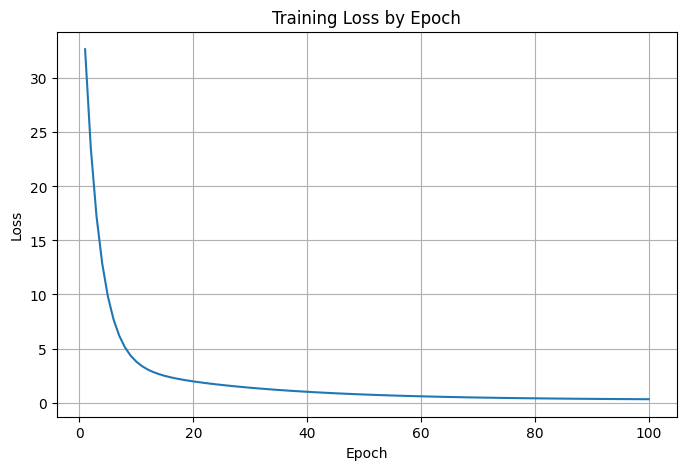

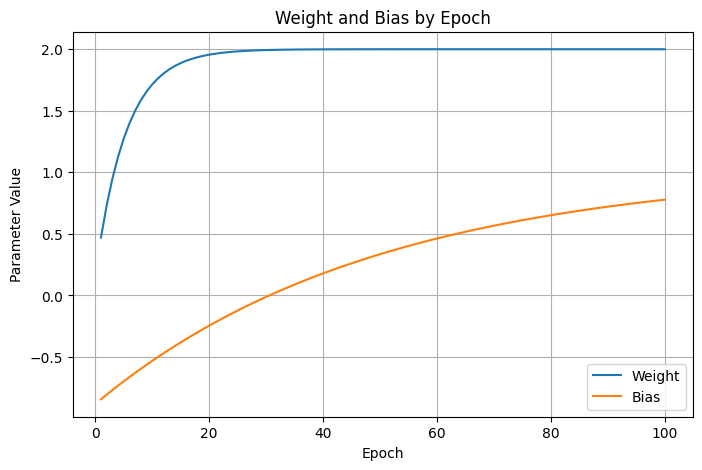

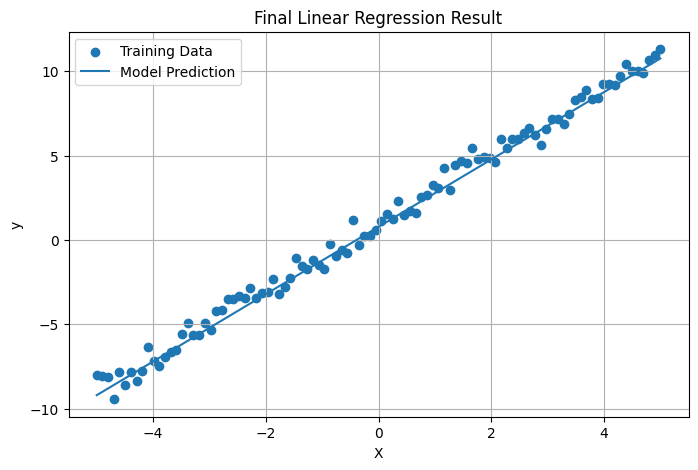

In [ ]:
# 학습이 끝난 뒤 최종 weight와 bias를 출력합니다.
# 데이터가 y = 2x + 1 근처로 만들어졌기 때문에 weight는 2, bias는 1에 가까워지는 것이 목표입니다.
print("최종 weight:", model.weight.item())
print("최종 bias:", model.bias.item())

# torch.no_grad()는 예측 과정에서 gradient 계산을 하지 않도록 설정합니다.
# 평가나 예측 단계에서는 역전파가 필요 없으므로 메모리와 계산량을 줄일 수 있습니다.
with torch.no_grad():
    # 학습된 모델을 사용하여 전체 X에 대한 예측값을 계산합니다.
    final_predictions = model(X)

    # 최종 손실값을 다시 계산합니다.
    final_loss = criterion(final_predictions, y)

# 최종 손실값을 출력합니다.
print("최종 손실값:", final_loss.item())

# figure()는 새로운 그래프 영역을 만듭니다.
# figsize는 그래프의 가로, 세로 크기를 지정합니다.
plt.figure(figsize=(8, 5))

# plot()은 x축과 y축 데이터를 이용하여 선 그래프를 그립니다.
# 여기서는 epoch가 증가할 때 loss가 어떻게 변하는지 확인합니다.
plt.plot(epoch_history, loss_history)

# title()은 그래프 제목을 설정합니다.
plt.title("Training Loss by Epoch")

# xlabel()은 x축 이름을 설정합니다.
plt.xlabel("Epoch")

# ylabel()은 y축 이름을 설정합니다.
plt.ylabel("Loss")

# grid()는 그래프에 격자선을 표시하여 값의 변화를 보기 쉽게 만듭니다.
plt.grid(True)

# show()는 완성된 그래프를 화면에 출력합니다.
plt.show()

# 새로운 그래프 영역을 만듭니다.
plt.figure(figsize=(8, 5))

# weight_history는 학습 중 weight가 어떻게 변했는지 보여줍니다.
plt.plot(epoch_history, weight_history, label="Weight")

# bias_history는 학습 중 bias가 어떻게 변했는지 보여줍니다.
plt.plot(epoch_history, bias_history, label="Bias")

# 그래프 제목을 설정합니다.
plt.title("Weight and Bias by Epoch")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Parameter Value")

# legend()는 label로 지정한 이름을 그래프 범례로 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 화면에 출력합니다.
plt.show()

# 새로운 그래프 영역을 만듭니다.
plt.figure(figsize=(8, 5))

# scatter()는 실제 학습 데이터를 점으로 표시합니다.
# X.detach()는 Tensor를 계산 그래프에서 분리하여 그래프 출력용 값으로 사용합니다.
plt.scatter(X.detach(), y.detach(), label="Training Data")

# plot()은 학습된 모델의 최종 예측선을 표시합니다.
# final_predictions.detach()는 예측 결과를 계산 그래프에서 분리합니다.
plt.plot(X.detach(), final_predictions.detach(), label="Model Prediction")

# 그래프 제목을 설정합니다.
plt.title("Final Linear Regression Result")

# x축 이름을 설정합니다.
plt.xlabel("X")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 화면에 출력합니다.
plt.show()
